In [1]:
from math import sqrt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import scipy as sp
import scipy.sparse as scs
import matplotlib
import matplotlib.pyplot as plt
from numpy.linalg import svd
from sklearn.manifold import TSNE
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm


In [2]:
df = pd.read_csv('/home/fltww/Загрузки/df_electronics.csv')

In [24]:
df.head()

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,0,0,5.0,1999-06-13,Female,Portable Audio & Video,NaN,1999,NaN,0
1,0,1,5.0,1999-06-14,Female,Portable Audio & Video,NaN,1999,NaN,0
2,0,2,3.0,1999-06-17,Female,Portable Audio & Video,NaN,1999,NaN,0
3,0,3,1.0,1999-07-01,Female,Portable Audio & Video,NaN,1999,NaN,0
4,0,4,2.0,1999-07-06,Female,Portable Audio & Video,NaN,1999,NaN,0


In [6]:
num_users, num_items = df.user_id.unique(), df.item_id.unique()

In [3]:

df['last_watch_dt'] = (pd.to_datetime(df['timestamp']) - pd.to_datetime(df['timestamp']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))

<AxesSubplot:xlabel='index'>

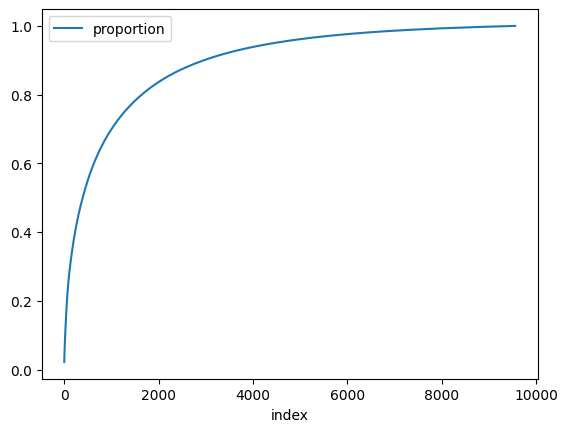

In [26]:

g = df.item_id.value_counts(normalize=True).cumsum().reset_index()

g.columns = ['item_id', 'proportion']

g = g.reset_index()

g.plot(x='index', y='proportion')


<AxesSubplot:>

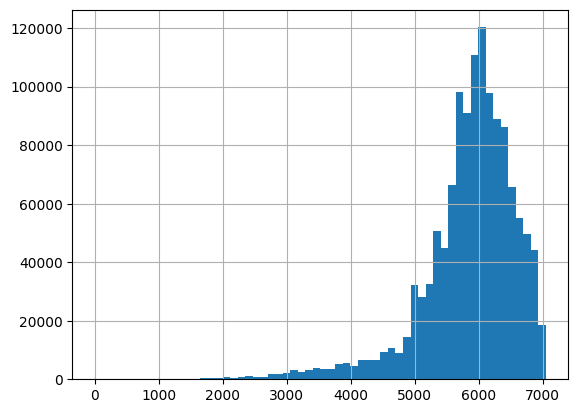

In [27]:
df.last_watch_dt.hist(bins=60)


In [7]:
train_df = df[df['last_watch_dt'] < 6500].copy()

test_df = df[df['last_watch_dt'] >= 6500].copy()


In [5]:
only_in_train = np.setdiff1d(train_df.user_id.unique(), test_df.user_id.unique())
only_in_test = np.setdiff1d(test_df.user_id.unique(), train_df.user_id.unique())

count_only_in_one = len(only_in_train) + len(only_in_test)

In [6]:
print(f'only train: {len(only_in_train)}, only test {len(only_in_test)}, only_one:{count_only_in_one}')

only train: 956123, only test 184372, only_one:1140495


In [31]:
len(np.intersect1d(train_df.user_id.unique(),test_df.user_id.unique() ))

17138

In [8]:
# all_included = np.intersect1d(train_df.user_id.unique(),test_df.user_id.unique() )
train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  17138
число людей всего: 973261


In [33]:
df.last_watch_dt.isnull().sum()

0

In [9]:
train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()

test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
# assert len(train_df.user_id.unique()) == num_users
# assert len(test_df.user_id.unique()) == num_users

In [36]:
train_df.head()

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split,last_watch_dt
446,40,440,5.0,2001-08-16,Female,Camera & Photo,Olympus,2002,NaN,0,795
554,39,545,5.0,2001-12-03,Female,Camera & Photo,Sony,2001,Male,0,904
732,0,720,5.0,2002-02-25,Female,Portable Audio & Video,NaN,1999,NaN,0,988
745,1,732,3.0,2002-03-14,Female,Computers & Accessories,HP,2000,NaN,0,1005
780,3,766,2.0,2002-04-17,Female,Camera & Photo,NaN,2005,NaN,0,1039


In [37]:
test_df.head()

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split,last_watch_dt
1084235,3299,766769,3.0,2017-03-30,Male,Computers & Accessories,NaN,2013,NaN,1,6500
1084259,5113,656393,5.0,2017-03-30,Female,Accessories & Supplies,NaN,2014,NaN,2,6500
1084268,3106,29639,4.0,2017-03-30,Female,Computers & Accessories,Bose,2013,Male,2,6500
1084276,6255,171016,3.0,2017-03-30,Female&Male,Headphones,NaN,2015,NaN,2,6500
1084284,6630,909774,5.0,2017-03-30,Male,Computers & Accessories,NaN,2015,NaN,2,6500


In [10]:
train_group = train_df.groupby('user_id').apply(
    lambda x : [(t1, t2) for t1, t2 in sorted(zip(x.item_id, x.last_watch_dt), key=lambda x : x[1])]
).reset_index()


test_group = test_df.groupby('user_id').apply(
    lambda x : [(t1, t2) for t1, t2 in sorted(zip(x.item_id, x.last_watch_dt), key=lambda x : x[1])]
).reset_index()

test_group.rename({0 : 'test_interactions'}, axis=1, inplace=True)

train_group.rename({0 : 'train_interactions'}, axis=1, inplace=True)


In [39]:
train_group

,user_id,train_interactions
0,440,"[(40, 795), (2593, 5097), (3460, 5883)]"
1,545,"[(39, 904), (2237, 6160)]"
2,720,"[(0, 988)]"
3,732,"[(1, 1005), (1281, 4594)]"
4,766,"[(3, 1039)]"
...,...,...
17133,973016,"[(5071, 6499)]"
17134,973069,"[(7904, 6499)]"
17135,973071,"[(5884, 6499)]"
17136,973172,"[(521, 6499)]"


In [20]:
test_group

,user_id,test_interactions
0,47,"[(14488, 160)]"
1,157,"[(16228, 156), (2616, 160)]"
2,165,"[(4969, 161)]"
3,170,"[(1453, 153), (741, 154), (15679, 154), (11083..."
4,189,"[(12360, 155), (6898, 155), (4549, 160), (582,..."
...,...,...
19995,1097376,"[(12360, 159)]"
19996,1097444,"[(1124, 153), (5733, 153), (7761, 153), (13591..."
19997,1097471,"[(1785, 158), (10942, 161), (682, 161), (4927,..."
19998,1097508,"[(10986, 162), (9985, 162)]"


In [11]:
joined = train_group.merge(test_group)

In [41]:
joined

,user_id,train_interactions,test_interactions
0,440,"[(40, 795), (2593, 5097), (3460, 5883)]","[(5897, 6937)]"
1,545,"[(39, 904), (2237, 6160)]","[(1875, 6567)]"
2,720,"[(0, 988)]","[(7022, 6870)]"
3,732,"[(1, 1005), (1281, 4594)]","[(4718, 6985)]"
4,766,"[(3, 1039)]","[(8167, 6771)]"
...,...,...,...
17133,973016,"[(5071, 6499)]","[(6689, 6514)]"
17134,973069,"[(7904, 6499)]","[(1395, 6794)]"
17135,973071,"[(5884, 6499)]","[(7780, 6745)]"
17136,973172,"[(521, 6499)]","[(4718, 6931)]"


In [42]:
class Random_fit:
  def __init__(self):
    self.trained = False

  def fit(self,  df, col='train_interactions'):

    items = set()

    for _, row in df.iterrows():
      for item, _ in row[col]:
        items.add(item)

    self.items = items
    self.trained = True

  def predict(self, df, top_n=10):
    assert self.trained == True

    return [np.random.choice(list(self.items), replace=False, size=top_n)] * len(df)





In [44]:
random = Random_fit()

random.fit(joined)

joined['random_items'] = random.predict(joined, top_n=5)

In [45]:
joined

,user_id,train_interactions,test_interactions,random_items
0,440,"[(40, 795), (2593, 5097), (3460, 5883)]","[(5897, 6937)]","[912, 4700, 830, 8848, 6995]"
1,545,"[(39, 904), (2237, 6160)]","[(1875, 6567)]","[912, 4700, 830, 8848, 6995]"
2,720,"[(0, 988)]","[(7022, 6870)]","[912, 4700, 830, 8848, 6995]"
3,732,"[(1, 1005), (1281, 4594)]","[(4718, 6985)]","[912, 4700, 830, 8848, 6995]"
4,766,"[(3, 1039)]","[(8167, 6771)]","[912, 4700, 830, 8848, 6995]"
...,...,...,...,...
17133,973016,"[(5071, 6499)]","[(6689, 6514)]","[912, 4700, 830, 8848, 6995]"
17134,973069,"[(7904, 6499)]","[(1395, 6794)]","[912, 4700, 830, 8848, 6995]"
17135,973071,"[(5884, 6499)]","[(7780, 6745)]","[912, 4700, 830, 8848, 6995]"
17136,973172,"[(521, 6499)]","[(4718, 6931)]","[912, 4700, 830, 8848, 6995]"


In [12]:
def ap_metric(gt_items, predictions, topn):

  predictions = predictions[:topn]

  relev = np.isin(predictions, gt_items).astype(int)

  precision_k = np.cumsum(relev) / np.arange(1, len(predictions) + 1)

  ap = (relev * precision_k).sum() / min(topn, len(gt_items))

  return ap

def rr_metric(gt_items, predictions, topn):
    predictions = predictions[:topn]

    for rank, item in enumerate(predictions, start=1):

      if item in gt_items:
        return 1 / rank

    return 0
def ndcg_metric(gt_items, predicted):

    at = len(predicted)
    relevance = np.array([1 if x in predicted else 0 for x in gt_items])
  
    rank_dcg = dcg(relevance)

    if rank_dcg == 0.0:
        return 0.0

    # IDCG has all relevances to 1 (or the values provided), up to the number of items in the test set that can fit in the list length
    ideal_dcg = dcg(np.sort(relevance)[::-1][:at])

    if ideal_dcg == 0.0:
        return 0.0

    ndcg_ = rank_dcg / ideal_dcg

    return ndcg_


def dcg(scores):
    return np.sum(
        np.divide(np.power(2, scores) - 1, np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)), dtype=np.float64
    )


def recall_metric(gt_items, predicted):

    n_gt = len(gt_items)
    intersection = len(set(gt_items).intersection(set(predicted)))
    return intersection / n_gt



def hr_metric(gt_items, predictions,topn):

    return any(pred in gt_items for pred in predictions[:topn])

In [13]:


def evaluate_recommender(df, model_preds, gt_col='test_interactions'):

    metric_values = []

    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        predictions = row[model_preds]

        ap = ap_metric(gt_items, predictions, topn=len(gt_items))
        rr = rr_metric(gt_items, predictions, topn=len(gt_items))
        hr = hr_metric(gt_items, predictions, topn=len(gt_items))
        ndcg = ndcg_metric(gt_items, predictions)
        recall = recall_metric(gt_items, predictions)

        metric_values.append((ap, rr, hr, ndcg, recall))

    return {'map': np.mean([x[0] for x in metric_values]),
            'mrr': np.mean([x[1] for x in metric_values]),
            'hr': np.mean([x[2] for x in metric_values]),
           'ndcg' : np.mean([x[3] for x in metric_values]),
           'recall' : np.mean([x[4] for x in metric_values])}



In [48]:
evaluate_recommender(joined, model_preds='random_items')

{'map': 0.0, 'mrr': 0.0, 'hr': 0.0, 'ndcg': 0.0, 'recall': 0.0}

In [49]:
class TopPopularRecs:
    def __init__(self):
        self.trained = False
        
    def fit(self, df, col='train_interactions'):
        
        counts = {}
        for _, row in df.iterrows():
            for item, _ in row[col]:
                if item in counts:
                    counts[item] += 1
                else:
                    counts[item] = 1
        sorted_counts = sorted(counts.items(), key=lambda x : x[1], reverse=True)
        
        self.recommendation = [x[0] for x in sorted_counts]
        self.trained = True
        
    def predict(self, df, topn):
        assert self.trained 
        
        return [self.recommendation[:topn]] * len(df)
        
        
        
        
        
        
        

In [96]:
top = TopPopularRecs()

top.fit(joined)

joined['top_popular_recs'] = top.predict(joined, 18)

In [97]:
joined

,user_id,train_interactions,test_interactions,random_items,top_popular_recs,window_1_rec,window_2_rec,window_3_rec,window_4_rec,als_rec
0,440,"[(40, 795), (2593, 5097), (3460, 5883)]","[(5897, 6937)]","[912, 4700, 830, 8848, 6995]","[7780, 2031, 2279, 1575, 1124, 468, 274, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 2031, 6378, 162, 5054]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[2279, 2031, 468, 1124, 274, 1886, 1575, 1605,..."
1,545,"[(39, 904), (2237, 6160)]","[(1875, 6567)]","[912, 4700, 830, 8848, 6995]","[7780, 2031, 2279, 1575, 1124, 468, 274, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 2031, 6378, 162, 5054]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[1124, 274, 468, 1715, 1575, 2279, 2031, 2466,..."
2,720,"[(0, 988)]","[(7022, 6870)]","[912, 4700, 830, 8848, 6995]","[7780, 2031, 2279, 1575, 1124, 468, 274, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 2031, 6378, 162, 5054]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[2031, 2279, 468, 274, 1575, 1886, 2466, 1715,..."
3,732,"[(1, 1005), (1281, 4594)]","[(4718, 6985)]","[912, 4700, 830, 8848, 6995]","[7780, 2031, 2279, 1575, 1124, 468, 274, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 2031, 6378, 162, 5054]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[2031, 1575, 468, 2279, 1605, 3630, 457, 1470,..."
4,766,"[(3, 1039)]","[(8167, 6771)]","[912, 4700, 830, 8848, 6995]","[7780, 2031, 2279, 1575, 1124, 468, 274, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 2031, 6378, 162, 5054]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[1124, 468, 274, 7780, 1715, 2279, 1575, 1886,..."
...,...,...,...,...,...,...,...,...,...,...
17133,973016,"[(5071, 6499)]","[(6689, 6514)]","[912, 4700, 830, 8848, 6995]","[7780, 2031, 2279, 1575, 1124, 468, 274, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 2031, 6378, 162, 5054]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[7780, 2031, 2279, 1575, 468, 1124, 274, 1605,..."
17134,973069,"[(7904, 6499)]","[(1395, 6794)]","[912, 4700, 830, 8848, 6995]","[7780, 2031, 2279, 1575, 1124, 468, 274, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 2031, 6378, 162, 5054]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[7780, 1124, 1575, 1605, 2279, 1886, 111, 468,..."
17135,973071,"[(5884, 6499)]","[(7780, 6745)]","[912, 4700, 830, 8848, 6995]","[7780, 2031, 2279, 1575, 1124, 468, 274, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 2031, 6378, 162, 5054]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[468, 2031, 1124, 7780, 2279, 1605, 1575, 274,..."
17136,973172,"[(521, 6499)]","[(4718, 6931)]","[912, 4700, 830, 8848, 6995]","[7780, 2031, 2279, 1575, 1124, 468, 274, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 2031, 6378, 162, 5054]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[2031, 274, 468, 1575, 1715, 1124, 2279, 1470,..."


In [98]:
evaluate_recommender(joined, model_preds='top_popular_recs')

{'map': 0.053846390736634636,
 'mrr': 0.05739681798731863,
 'hr': 0.058699964990080525,
 'ndcg': 0.13849072759864847,
 'recall': 0.1332409460458241}

In [53]:
class TopWeightedPopular:
    def __init__(self, min_window):
        super().__init__()
        self.min_window = min_window
        self.trained = False
        
    def fit(self, df, col='train_interactions'):
        window_size = 30 * self.min_window
        counts = {}
        for _, row in df.iterrows():
            for item, time in row[col]:
                if time >= 6500 - window_size :
                    if item in counts:
                        counts[item] += 1
                    else:
                        counts[item] = 1
        top_pop_counts_per_last_month = sorted(counts.items(), key=lambda x :x[1], reverse=True)
        
        self.fit_rec = [x[0] for x in top_pop_counts_per_last_month]
        self.trained = True
        
    def predict(self, df, topn):
        assert self.trained
        
        self.recomend = [self.fit_rec[:topn]] * len(df)
        return self.recomend
        
        
                        
        
        
        
        

In [54]:
maps = []

mrrs = []

hrs = []

ndcgs = []

recalls = []

for w_size in range(1, 5):
    topn = TopWeightedPopular(min_window=w_size)
    topn.fit(joined)
    
    predict = topn.predict(joined, topn=5)
    
    joined[f'window_{w_size}_rec'] = predict
    
    map, mrr, hr, ndcg, recall = evaluate_recommender(joined, f'window_{w_size}_rec').values()
    
    maps.append(map)
    mrrs.append(mrr)
    hrs.append(hr)
    ndcgs.append(ndcg)
    recalls.append(recall)

    

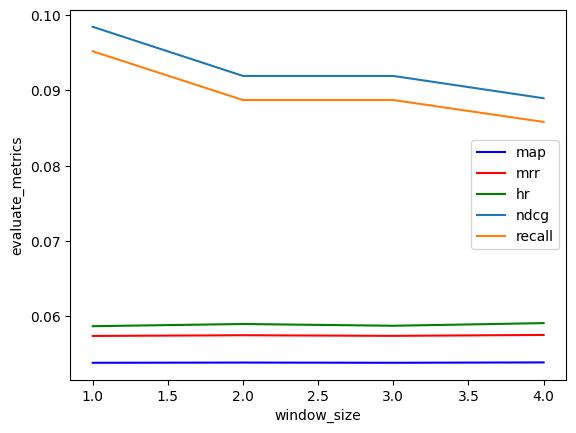

In [55]:
x = np.arange(1, 5)

plt.plot(x, maps, label='map', color='blue')
plt.plot(x, mrrs, label='mrr', color='red')
plt.plot(x, hrs, label='hr', color='green')
plt.plot(x, ndcgs, label='ndcg')
plt.plot(x, recalls, label='recall')

plt.xlabel('window_size')
plt.ylabel('evaluate_metrics')
plt.legend()

In [56]:
df = joined.copy()

ks = np.arange(1, 100)

maps = []

mrrs = []

hrs = []

ndcgs = []

recalls = []

for k in ks:
    df[f'predict_{k}'] = top.predict(df, topn=k)
    
    map, mrr, hr, ndcg, recall = evaluate_recommender(df, f'predict_{k}').values()
    
    maps.append(map)
    mrrs.append(mrr)
    hrs.append(hr)
    ndcgs.append(ndcg)
    recalls.append(recall)

    

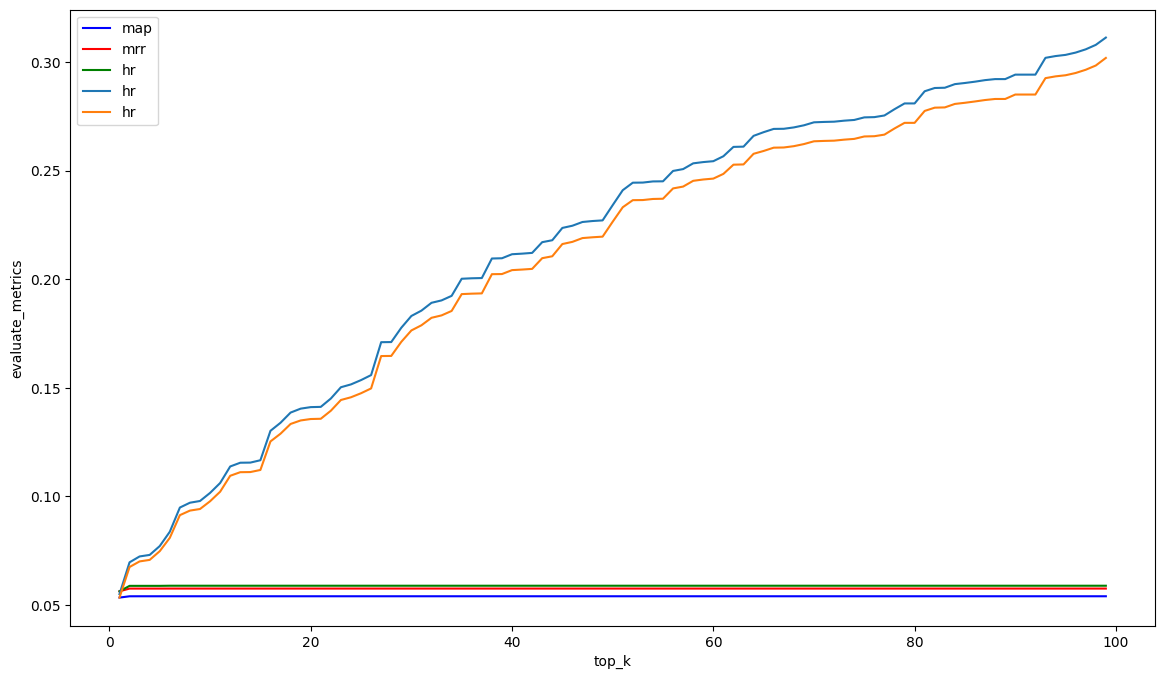

In [57]:
plt.figure(figsize=(14, 8))

plt.plot(ks, maps, label='map', color='blue')
plt.plot(ks, mrrs, label='mrr', color='red')
plt.plot(ks, hrs, label='hr', color='green')
plt.plot(ks, ndcgs, label='hr')
plt.plot(ks, recalls, label='hr')

plt.xlabel('top_k')
plt.ylabel('evaluate_metrics')
plt.legend()

In [33]:
items = pd.read_csv('/home/fltww/Загрузки/items.csv')
items.head()

data = pd.read_csv('/home/fltww/Загрузки/interactions.csv')

In [34]:
popular_items = data.item_id.value_counts()[:150].index.to_list()
random = np.random.choice(popular_items, size=5)

random_name = items[items.item_id.isin(random)].title

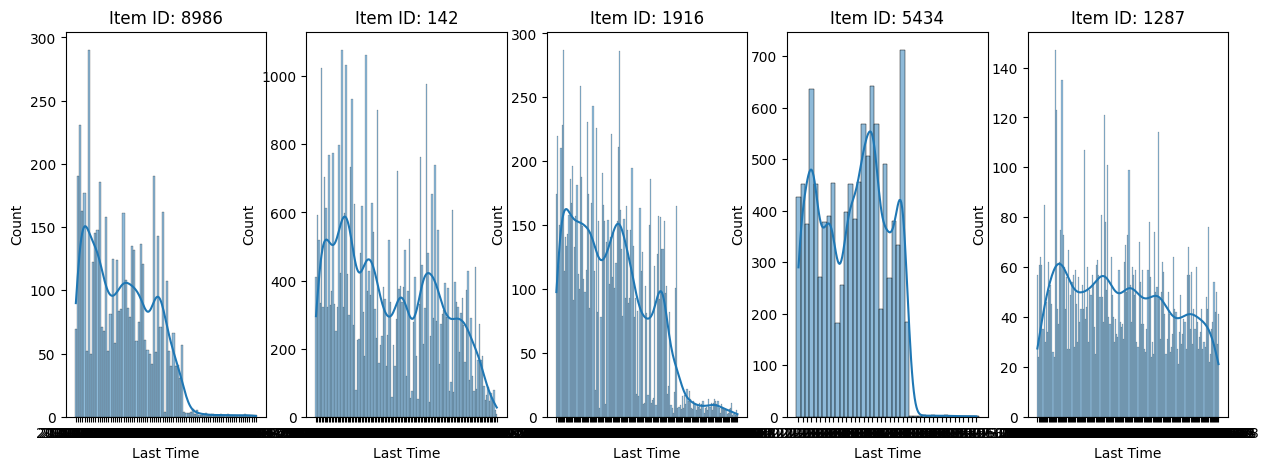

In [36]:


fig, axes = plt.subplots(1, len(random), figsize=(15, 5))

# Построение гистограмм
for ax, item_id in zip(axes, random):
    subset = data[data["item_id"] == item_id]
    
    # Строим гистограмму по last_time
    sns.histplot(subset["last_watch_dt"], ax=ax, kde=True, bins=30)
    ax.set_title(f"Item ID: {item_id}")
    ax.set_xlabel("Last Time") 
    ax.set_ylabel("Count")      


In [53]:
!pip install implicit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 3.1 MB/s eta 0:00:00m eta 0:00:010:00:01


In [14]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
from implicit.als import AlternatingLeastSquares
from tqdm.auto import tqdm

class ImplicitAlS:
    def __init__(self, model):
        self.model = model
        self.trained = False
        self.train_df = train_df
        
    def fit(self, train_df):
        self.user_encoder = LabelEncoder()
        self.item_encoder = LabelEncoder()
        self.user_encoder.fit(train_df['user_id'])
        self.item_encoder.fit(train_df['item_id'])
        
        self.train_ratings = self.encode_table(train_df, ['user_id', 'item_id'])
        self.model.fit(self.train_ratings)
        self.trained = True
        
    def predict(self, test_df, top_k=100, rerank_weights=None, external_scores=None):
        
        if not self.trained:
            raise ValueError('Model is not trained yet')
        
        user_to_predict = test_df['user_id']
        encoded_users = self.user_encoder.transform(user_to_predict)
        
        user_recs, scores = self.model.recommend(
            encoded_users, self.train_ratings[encoded_users], 
            N=top_k, filter_already_liked_items=True
        )
        
        recs = [self.item_encoder.inverse_transform(x) for x in user_recs]
        
        if rerank_weights:
            scores = np.array(scores)
            for i, user in enumerate(encoded_users):
                user_weights = rerank_weights.get(user, {})
                scores[i] *= np.array([user_weights.get(item, 1.0) for item in user_recs[i]])
        
        if external_scores:
            for i, user in enumerate(encoded_users):
                scores[i] += np.array([external_scores.get(item, 0.0) for item in user_recs[i]])
        
        reranked_indices = np.argsort(-scores, axis=1)
        user_recs = np.take_along_axis(user_recs, reranked_indices, axis=1)
        recs = [self.item_encoder.inverse_transform(x) for x in user_recs]

        return recs
    
    def encode_table(self, df, axis_names):
        user_ids = self.user_encoder.transform(df[axis_names[0]])
        item_ids = self.item_encoder.transform(df[axis_names[1]])
        
        matrix_shape = (len(self.user_encoder.classes_), len(self.item_encoder.classes_))
        sparse = csr_matrix((np.ones(len(user_ids)), (user_ids, item_ids)), shape=matrix_shape, dtype=np.float32)
        return sparse

In [15]:
from itertools import product

factors = [20, 50, 100]
regularizations = [0.001, 0.01, 0.1]
iterations = [10, 30, 50]

best_model = None
best_score = -1
dfff = joined.copy()
for f, reg, it in product(factors, regularizations, iterations):
    als = AlternatingLeastSquares(factors=f, iterations=it, 
                                  regularization=reg, calculate_training_loss=True)
    als_recommender = ImplicitAlS(als)
    als_recommender.fit(train_df)
    predict = als_recommender.predict(dfff, rerank_weights={'i1': 1.5, 'i2': 1.0, 'i3': 0.5},
    external_scores={'i1': 0.8, 'i2': 0.4, 'i3': 0.2},  
    top_k=18)
    dfff[f'als with factors{f} reg{reg} it{it}'] = predict
    score = evaluate_recommender(dfff, model_preds=f'als with factors{f} reg{reg} it{it}').get('ndcg')  
    print(f"factors: {f}, reg: {reg}, iterations: {it}, score: {score}")
    
    if score > best_score:
        best_score = score
        best_model = als_recommender

print(f"Лучшие параметры: factors={best_model.model.factors}, regularization={best_model.model.regularization}, iterations={best_model.model.iterations}")

  0%|          | 0/10 [00:00<?, ?it/s]

factors: 20, reg: 0.001, iterations: 10, score: 0.06649903672384086


  0%|          | 0/30 [00:00<?, ?it/s]

factors: 20, reg: 0.001, iterations: 30, score: 0.06613365806196998


  0%|          | 0/50 [00:00<?, ?it/s]

...

factors: 100, reg: 0.1, iterations: 10, score: 0.029661270285385188


  0%|          | 0/30 [00:00<?, ?it/s]

factors: 100, reg: 0.1, iterations: 30, score: 0.03257123083196935


  0%|          | 0/50 [00:00<?, ?it/s]

factors: 100, reg: 0.1, iterations: 50, score: 0.03149939804830564
Лучшие параметры: factors=20, regularization=0.01, iterations=10


In [16]:
train_df = train_df.fillna(0)
als = AlternatingLeastSquares(factors=best_model.model.factors, iterations=best_model.model.iterations, 
                              regularization=best_model.model.iterations, calculate_training_loss=True )
als_recommender = ImplicitAlS(als)
als_recommender.fit(train_df)


  0%|          | 0/10 [00:00<?, ?it/s]

In [17]:
predict_als = als_recommender.predict(joined, rerank_weights={'i1': 1.5, 'i2': 1.0, 'i3': 0.5},
    external_scores={'i1': 0.8, 'i2': 0.4, 'i3': 0.2},  
    top_k=18)

joined['als_rec'] = predict_als
joined

,user_id,train_interactions,test_interactions,als_rec
0,440,"[(40, 795), (2593, 5097), (3460, 5883)]","[(5897, 6937)]","[2031, 2279, 274, 1124, 468, 1575, 1886, 1605,..."
1,545,"[(39, 904), (2237, 6160)]","[(1875, 6567)]","[1124, 274, 468, 1605, 1575, 2031, 2279, 1715,..."
2,720,"[(0, 988)]","[(7022, 6870)]","[468, 1124, 6007, 2747, 6674, 8193, 5435, 8747..."
3,732,"[(1, 1005), (1281, 4594)]","[(4718, 6985)]","[7780, 2031, 1605, 468, 2279, 5795, 1124, 111,..."
4,766,"[(3, 1039)]","[(8167, 6771)]","[1124, 468, 274, 7780, 1605, 2279, 1886, 2466,..."
...,...,...,...,...
17133,973016,"[(5071, 6499)]","[(6689, 6514)]","[7780, 2031, 1124, 1575, 2279, 1605, 274, 5795..."
17134,973069,"[(7904, 6499)]","[(1395, 6794)]","[7780, 274, 1575, 1124, 1605, 1886, 2279, 468,..."
17135,973071,"[(5884, 6499)]","[(7780, 6745)]","[468, 1124, 2031, 274, 7780, 1575, 1886, 1715,..."
17136,973172,"[(521, 6499)]","[(4718, 6931)]","[2031, 274, 468, 1715, 1886, 1605, 1470, 111, ..."


In [18]:
evaluate_recommender(joined, model_preds='als_rec')

{'map': 0.015501290180365921,
 'mrr': 0.017179172987902124,
 'hr': 0.018321857859726922,
 'ndcg': 0.1097883560279964,
 'recall': 0.10482261640798225}

In [126]:
class UserRecommend:
    def __init__(self, is_new):
        self.is_new = is_new
        
    def recommend(self):
        if self.is_new:
            predict = top.predict(joined, topn=18)
            return list(predict)[0]
        else :
            predict_als = als_recommender.predict(
            test_df=test,
            rerank_weights={'i1': 1.5, 'i2': 1.0, 'i3': 0.5},
            external_scores={'i1': 0.8, 'i2': 0.4, 'i3': 0.2},  
            top_k=18
            )
            
            return predict_als
            
            
            
            
        

        
        